# Hotel Review Sentiment Analysis & Topic Modelling
### NLP Coursework — End-to-End Pipeline

**Dataset:** 515K TripAdvisor Hotel Reviews (Kaggle — jiashenliu)  
**Techniques:** Text preprocessing · TF-IDF · Word2Vec · VADER · TextBlob · BERT · LDA · ML Classifiers  
**Author:** MOHAMMED IFTEKHAR

---

## Table of Contents
1. [Environment Setup & Imports](#part1)
2. [Data Loading & Exploratory Data Analysis](#part2)
3. [Text Preprocessing Pipeline](#part3)
4. [Feature Engineering (TF-IDF & Word2Vec)](#part4)
5. [Lexicon Sentiment Analysis (VADER & TextBlob)](#part5)
6. [Transformer-Based Sentiment (BERT)](#part6)
7. [N-gram Analysis & Word Clouds](#part7)
8. [Topic Modelling with LDA](#part8)
9. [Machine Learning Classification](#part9)
10. [Model Evaluation & Comparison](#part10)
11. [Conclusions & Future Work](#part11)


---
<a id='part1'></a>
## Part 1 — Environment Setup & Imports


In [1]:
# Uncomment and run once to install all dependencies
# !pip install "numpy<2.0" nltk==3.9.1 pandas==2.2.3 matplotlib==3.10.0 \
#              textblob==0.18.0.post0 vaderSentiment==3.3.2 transformers==4.47.1 \
#              scikit-learn==1.6.0 gensim==4.3.3 seaborn==0.13.2 torch==2.5.1 \
#              wordcloud pyLDAvis chardet datasets

import re, warnings, logging
from collections import Counter
warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
PALETTE = sns.color_palette("muted")

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

for pkg in ['punkt_tab', 'wordnet', 'stopwords', 'vader_lexicon',
            'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, ConfusionMatrixDisplay)

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Word2Vec

print("All libraries loaded successfully.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | "
      f"scikit-learn {__import__('sklearn').__version__}")


All libraries loaded successfully.
NumPy 1.26.4 | Pandas 2.2.3 | scikit-learn 1.6.0


---
<a id='part2'></a>
## Part 2 — Data Loading & Exploratory Data Analysis

### Dataset columns (515K Kaggle CSV)

| Column | Type | Description |
|---|---|---|
| `Hotel_Name` | string | Hotel identifier |
| `Hotel_Address` | string | Full address |
| `Reviewer_Nationality` | string | Country of reviewer |
| `Positive_Review` | string | Positive text written by reviewer |
| `Negative_Review` | string | Negative text written by reviewer |
| `Reviewer_Score` | float | Score 2.5–10.0 |
| `Total_Number_of_Reviews` | int | Total reviews for that hotel |
| `Tags` | string | Trip type, room type, group size |
| `Review_Date` | string | Date of review |

We combine `Positive_Review` and `Negative_Review` into a single `full_review` column,  
and convert `Reviewer_Score` (2.5–10) into a 3-class sentiment label.


In [2]:
# ── Load the 515K dataset ─────────────────────────────────────────────────────
# Make sure Hotel_Reviews.csv is in the same folder as this notebook.
df_raw = pd.read_csv("Hotel_Reviews.csv")

print("Shape          :", df_raw.shape)
print("Columns        :", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)
print("\nFirst row sample:")
df_raw.head(2)


Shape          : (515738, 17)
Columns        : ['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']

Data types:
Hotel_Address                                  object
Additional_Number_of_Scoring                    int64
Review_Date                                    object
Average_Score                                 float64
Hotel_Name                                     object
Reviewer_Nationality                           object
Negative_Review                                object
Review_Total_Negative_Word_Counts               int64
Total_Number_of_Reviews                         int64
Positive_Review                                object
Review_Total_Positive_Word_Counts 

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968


In [3]:
# ── Missing values & duplicates ───────────────────────────────────────────────
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")


Missing values per column:
Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

Duplicate rows: 526


In [4]:
# ── Combine positive + negative text into one review column ──────────────────
# The dataset splits reviews into positive and negative halves.
# Rows where no positive/negative text was written contain the placeholder
# "No Positive" / "No Negative" — we remove those placeholders before joining.

def merge_review(row):
    pos = str(row['Positive_Review']).strip()
    neg = str(row['Negative_Review']).strip()
    # Remove placeholder strings
    pos = '' if pos.lower() in ('no positive', 'nothing', 'n/a', 'nan') else pos
    neg = '' if neg.lower() in ('no negative', 'nothing', 'n/a', 'nan') else neg
    return (pos + ' ' + neg).strip()

df_raw['full_review'] = df_raw.apply(merge_review, axis=1)

# Drop rows where both halves were empty placeholders
df_raw = df_raw[df_raw['full_review'].str.len() > 5].copy()
df_raw.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning placeholders: {len(df_raw):,}")
print("\nSample merged review:")
print(df_raw['full_review'].iloc[0])


Rows after cleaning placeholders: 514,234

Sample merged review:
Only the park outside of the hotel was beautiful I am so angry that i made this post available via all possible sites i use when planing my trips so no one will make the mistake of booking this place I made my booking via booking com We stayed for 6 nights in this hotel from 11 to 17 July Upon arrival we were placed in a small room on the 2nd floor of the hotel It turned out that this was not the room we booked I had specially reserved the 2 level duplex room so that we would have a big windows and high ceilings The room itself was ok if you don t mind the broken window that can not be closed hello rain and a mini fridge that contained some sort of a bio weapon at least i guessed so by the smell of it I intimately asked to change the room and after explaining 2 times that i booked a duplex btw it costs the same as a simple double but got way more volume due to the high ceiling was offered a room but only the next day SO i

Score stats:
count    514234.000000
mean          8.395329
std           1.636642
min           2.500000
25%           7.500000
50%           8.800000
75%           9.600000
max          10.000000
Name: Reviewer_Score, dtype: float64


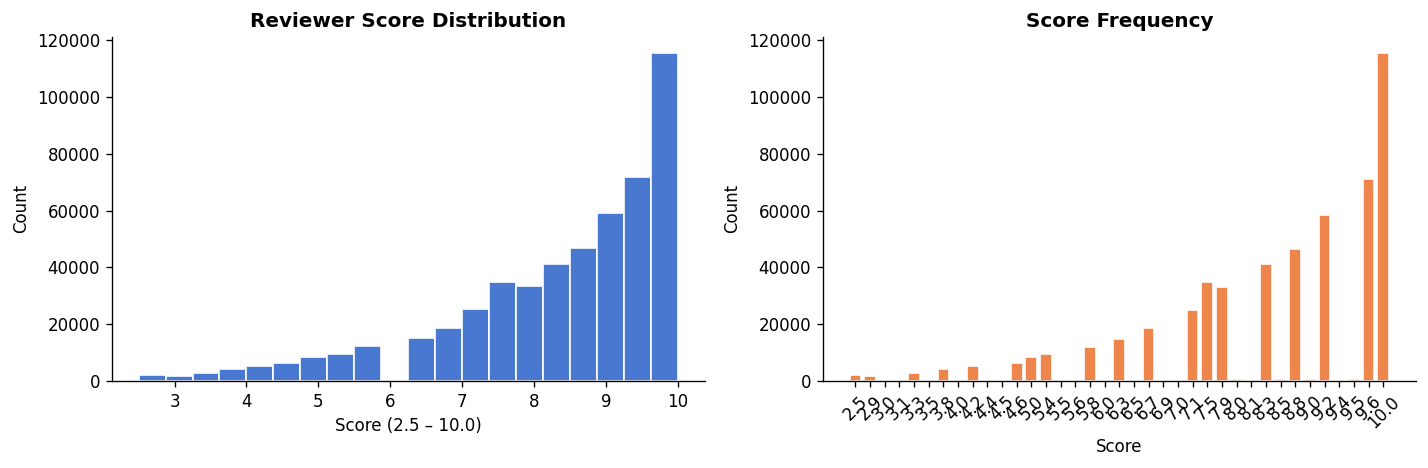

In [5]:
# ── Reviewer_Score: distribution ─────────────────────────────────────────────
# Scores range from 2.5 to 10.0 (NOT 1-5 like the small CSV)
print("Score stats:")
print(df_raw['Reviewer_Score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['Reviewer_Score'], bins=20, color=PALETTE[0], edgecolor='white')
axes[0].set_title("Reviewer Score Distribution", fontweight='bold')
axes[0].set_xlabel("Score (2.5 – 10.0)")
axes[0].set_ylabel("Count")

score_counts = df_raw['Reviewer_Score'].value_counts().sort_index()
axes[1].bar(score_counts.index.astype(str), score_counts.values,
            color=PALETTE[1], edgecolor='white')
axes[1].set_title("Score Frequency", fontweight='bold')
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("eda_score_distribution.png", bbox_inches='tight')
plt.show()


In [6]:
# ── Create 3-class sentiment label from Reviewer_Score ───────────────────────
# Score 2.5–5.0  → negative
# Score 5.1–7.0  → neutral
# Score 7.1–10.0 → positive
# These thresholds reflect natural clustering in TripAdvisor scores.

def score_to_sentiment(score):
    if score <= 5.0:
        return 'negative'
    elif score <= 7.0:
        return 'neutral'
    else:
        return 'positive'

df_raw['sentiment'] = df_raw['Reviewer_Score'].apply(score_to_sentiment)

print("Sentiment class distribution:")
print(df_raw['sentiment'].value_counts())
print("\nProportions:")
print(df_raw['sentiment'].value_counts(normalize=True).round(3))


Sentiment class distribution:
sentiment
positive    427251
neutral      56447
negative     30536
Name: count, dtype: int64

Proportions:
sentiment
positive    0.831
neutral     0.110
negative    0.059
Name: proportion, dtype: float64


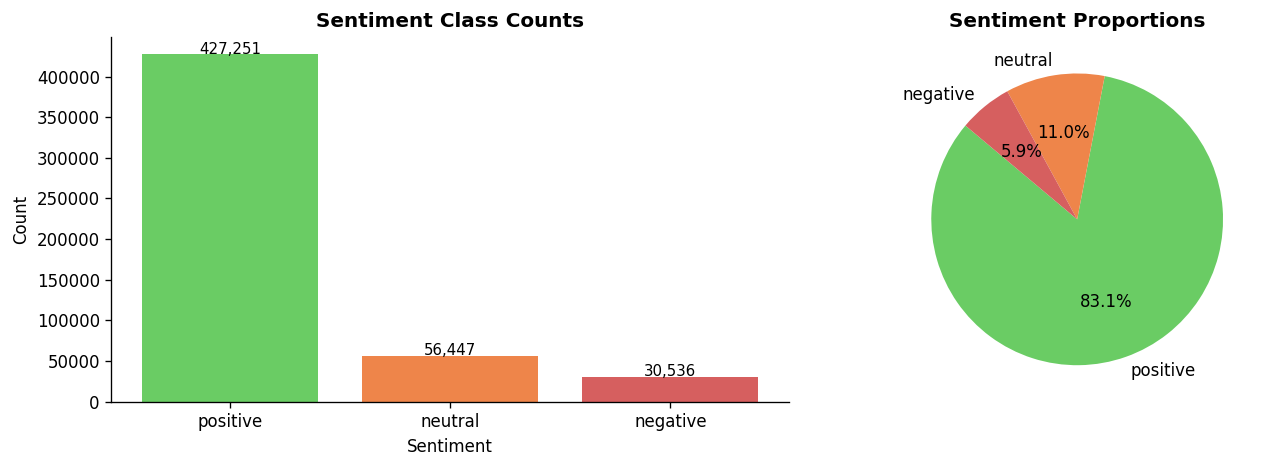

In [7]:
# ── Sentiment distribution pie ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[2], PALETTE[1], PALETTE[3]])
axes[0].set_title("Sentiment Class Counts", fontweight='bold')
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[PALETTE[2], PALETTE[1], PALETTE[3]], startangle=140)
axes[1].set_title("Sentiment Proportions", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_sentiment_distribution.png", bbox_inches='tight')
plt.show()


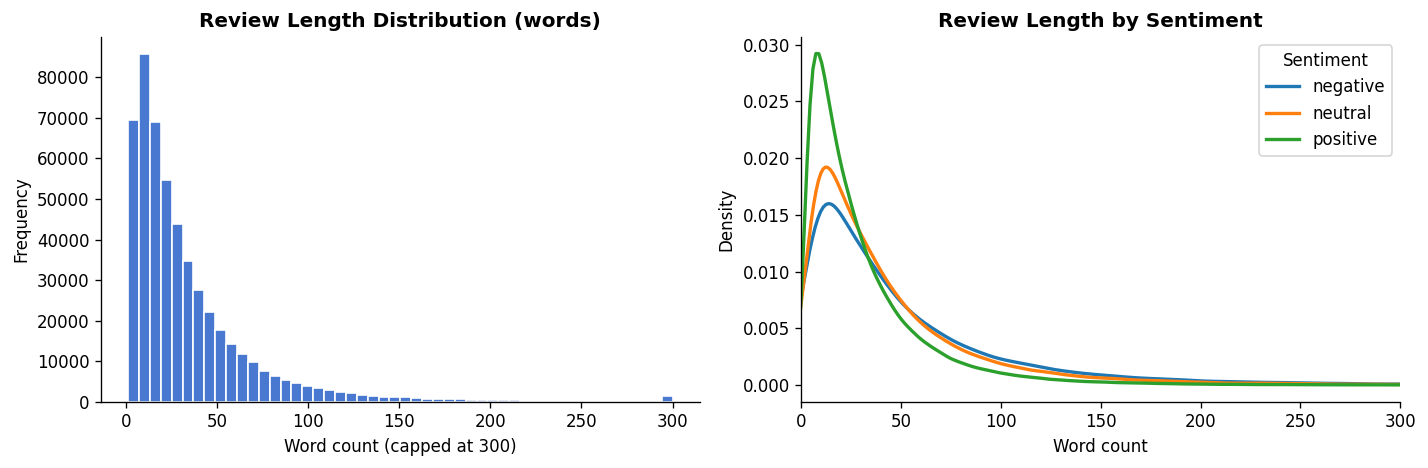

count    514234.0
mean         33.7
std          38.5
min           1.0
25%          11.0
50%          22.0
75%          43.0
max         733.0
Name: review_length, dtype: float64


In [8]:
# ── Review length analysis ────────────────────────────────────────────────────
df_raw['review_length'] = df_raw['full_review'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['review_length'].clip(upper=300), bins=50,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title("Review Length Distribution (words)", fontweight='bold')
axes[0].set_xlabel("Word count (capped at 300)")
axes[0].set_ylabel("Frequency")

df_raw.groupby('sentiment')['review_length'].plot.kde(ax=axes[1], lw=2)
axes[1].set_title("Review Length by Sentiment", fontweight='bold')
axes[1].set_xlabel("Word count")
axes[1].legend(title="Sentiment")
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.savefig("eda_review_length.png", bbox_inches='tight')
plt.show()
print(df_raw['review_length'].describe().round(1))


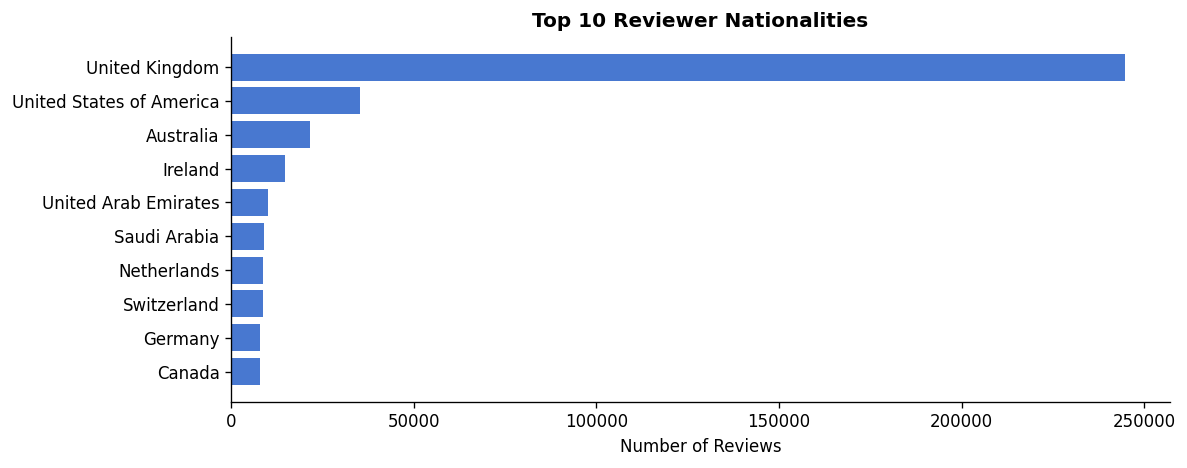

In [9]:
# ── Top 10 reviewer nationalities ────────────────────────────────────────────
top_nationalities = (df_raw['Reviewer_Nationality']
                     .str.strip()
                     .value_counts()
                     .head(10))

plt.figure(figsize=(10, 4))
plt.barh(top_nationalities.index[::-1], top_nationalities.values[::-1],
         color=PALETTE[0])
plt.title("Top 10 Reviewer Nationalities", fontweight='bold')
plt.xlabel("Number of Reviews")
plt.tight_layout()
plt.savefig("eda_nationalities.png", bbox_inches='tight')
plt.show()


In [10]:
# ── For faster processing: sample if dataset > 50K rows ──────────────────────
SAMPLE_SIZE = 50_000   # Increase or set to None to use full dataset

if SAMPLE_SIZE and len(df_raw) > SAMPLE_SIZE:
    df = (df_raw.groupby('sentiment', group_keys=False)
                .apply(lambda x: x.sample(
                    min(len(x), SAMPLE_SIZE // 3), random_state=42)))
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Stratified sample: {len(df):,} rows")
    print(df['sentiment'].value_counts())
else:
    df = df_raw.copy()
    print(f"Using full dataset: {len(df):,} rows")


Stratified sample: 49,998 rows
sentiment
positive    16666
negative    16666
neutral     16666
Name: count, dtype: int64


---
<a id='part3'></a>
## Part 3 — Text Preprocessing Pipeline

| Step | Operation | Rationale |
|---|---|---|
| 1 | Lowercase | Normalise casing |
| 2 | Remove URLs & HTML | Noise removal |
| 3 | Expand contractions | `don't → do not` |
| 4 | Replace `*` with `star` | Preserve rating signals |
| 5 | Remove punctuation & digits | Reduce vocabulary noise |
| 6 | Remove stopwords (keep negations) | Remove non-informative words |
| 7 | Tokenise (NLTK word_tokenize) | Split into word tokens |
| 8 | Stemming (Porter Stemmer) | Morphological reduction |
| 9 | Lemmatisation (WordNet) | Linguistically accurate normalisation |


In [11]:
# ── Stopwords: preserve negations ─────────────────────────────────────────────
EN_STOPWORDS = set(stopwords.words('english'))
NEGATIONS = {
    'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'without', "n't", 'cannot', "couldn't", "wouldn't",
    "shouldn't", "didn't", "doesn't", "isn't", "aren't", "wasn't",
    "weren't", "haven't"
}
EN_STOPWORDS -= NEGATIONS

# ── Contraction expander ───────────────────────────────────────────────────────
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'ve": " have", "'m": " am"
}

def expand_contractions(text: str) -> str:
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

# ── Core cleaning steps ────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'<.*?>', '', text)                     # HTML tags
    text = expand_contractions(text)
    text = re.sub(r'\*', ' star ', text)                  # * → star
    text = re.sub(r'[^\w\s]', '', text)                   # punctuation
    text = re.sub(r'\d+', '', text)                        # digits
    text = re.sub(r'\s+', ' ', text).strip()               # whitespace
    return text

def remove_stopwords(text: str) -> str:
    return ' '.join(w for w in text.split() if w not in EN_STOPWORDS)

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text: str) -> str:
    return ' '.join(stemmer.stem(w) for w in word_tokenize(text))

def lemmatize_text(text: str) -> str:
    return ' '.join(lemmatizer.lemmatize(w) for w in word_tokenize(text))

# ── Apply pipeline ────────────────────────────────────────────────────────────
print("Applying preprocessing pipeline (this may take a minute)...")

df['cleaned']      = df['full_review'].apply(clean_text)
df['no_stopwords'] = df['cleaned'].apply(remove_stopwords)
df['stemmed']      = df['no_stopwords'].apply(stem_text)
df['lemmatized']   = df['no_stopwords'].apply(lemmatize_text)
df['tokens']       = df['lemmatized'].apply(word_tokenize)

print(f"Done. Shape: {df.shape}")
df[['full_review', 'cleaned', 'stemmed', 'lemmatized']].head(2)


Applying preprocessing pipeline (this may take a minute)...
Done. Shape: (49998, 25)


,full_review,cleaned,stemmed,lemmatized
0,The bed was amazing Location is great Grotty c...,the bed was amazing location is great grotty c...,bed amaz locat great grotti carpet not clean,bed amazing location great grotty carpet not c...
1,The room was in Underground For this room the ...,the room was in underground for this room the ...,room underground room room fee expens euro night,room underground room room fee expensive euro ...


In [12]:
# ── Side-by-side preprocessing comparison ─────────────────────────────────────
idx = 0
print("ORIGINAL:   ", df['full_review'].iloc[idx][:200])
print()
print("CLEANED:    ", df['cleaned'].iloc[idx][:200])
print()
print("STEMMED:    ", df['stemmed'].iloc[idx][:200])
print()
print("LEMMATIZED: ", df['lemmatized'].iloc[idx][:200])
print()
print("TOKENS:     ", df['tokens'].iloc[idx][:25])


ORIGINAL:    The bed was amazing Location is great Grotty carpets not that clean

CLEANED:     the bed was amazing location is great grotty carpets not that clean

STEMMED:     bed amaz locat great grotti carpet not clean

LEMMATIZED:  bed amazing location great grotty carpet not clean

TOKENS:      ['bed', 'amazing', 'location', 'great', 'grotty', 'carpet', 'not', 'clean']


---
<a id='part4'></a>
## Part 4 — Feature Engineering

### TF-IDF (Term Frequency – Inverse Document Frequency)
Down-weights common words; captures discriminative terms.  
We use unigrams + bigrams with a 15,000-feature vocabulary.

### Word2Vec
Gensim Skip-gram model (100-dimensional).  
Document vectors = mean of word vectors.


In [13]:
# ── TF-IDF vectoriser ─────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),
    max_features = 15_000,
    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True,    # log(1+tf)
)

X_tfidf = tfidf.fit_transform(df['lemmatized'])
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix : {X_tfidf.shape}")
print(f"Sample features: {feature_names[:20].tolist()}")


TF-IDF matrix : (49998, 15000)
Sample features: ['abandoned', 'ability', 'abit', 'able', 'able check', 'able get', 'able help', 'able leave', 'able open', 'able sleep', 'able use', 'abroad', 'abrupt', 'absence', 'absolute', 'absolutely', 'absolutely amazing', 'absolutely disgusting', 'absolutely everything', 'absolutely fantastic']


In [14]:
# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Class counts :", dict(zip(le.classes_,
                                  [np.sum(y == i) for i in range(len(le.classes_))])))


Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Class counts : {'negative': 16666, 'neutral': 16666, 'positive': 16666}


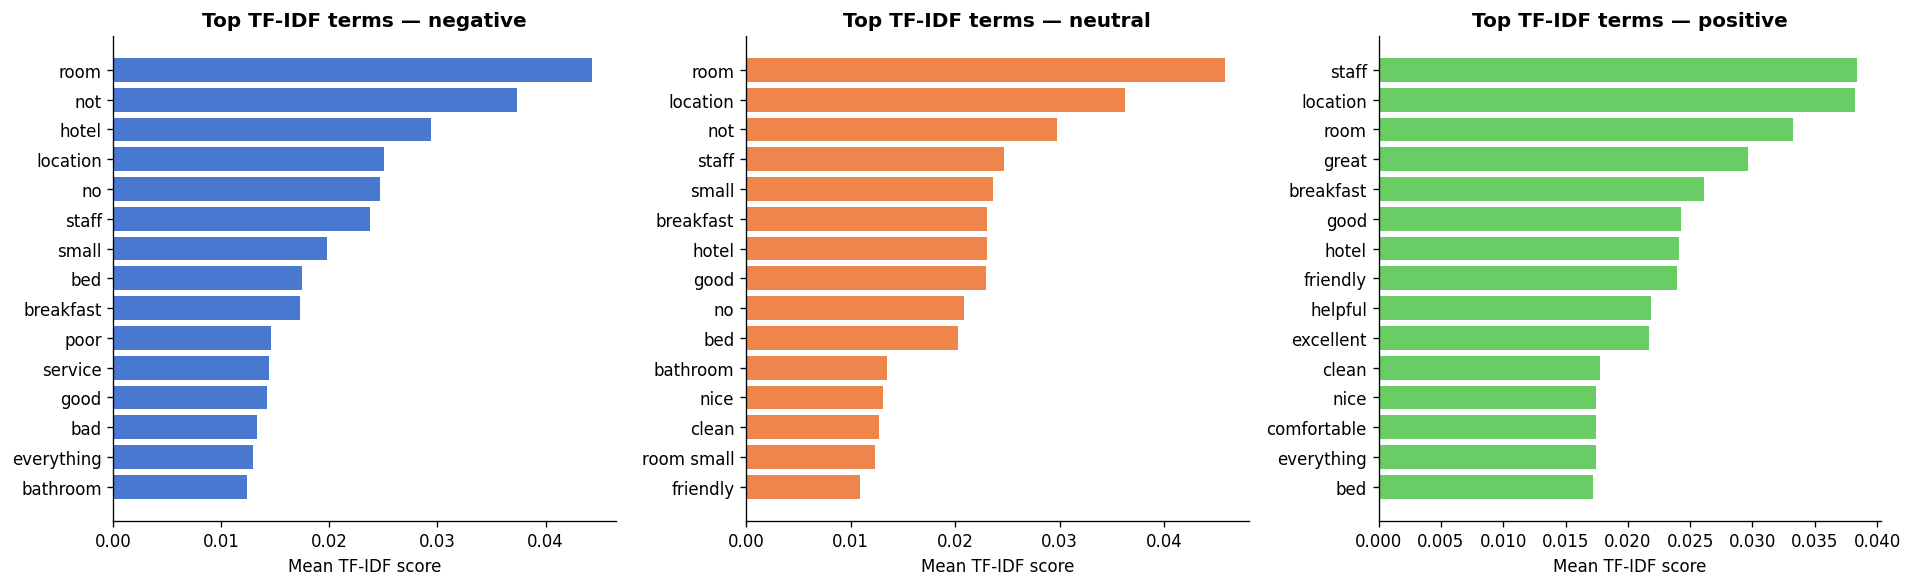

In [15]:
# ── Top TF-IDF terms per sentiment class ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, cls in enumerate(le.classes_):
    mask      = y == le.transform([cls])[0]
    mean_vals = X_tfidf[mask].mean(axis=0).A1
    top_idx   = mean_vals.argsort()[-15:][::-1]
    terms     = [feature_names[j] for j in top_idx]
    scores    = [mean_vals[j]     for j in top_idx]

    axes[i].barh(terms[::-1], scores[::-1], color=PALETTE[i])
    axes[i].set_title(f"Top TF-IDF terms — {cls}", fontweight='bold')
    axes[i].set_xlabel("Mean TF-IDF score")

plt.tight_layout()
plt.savefig("tfidf_top_terms.png", bbox_inches='tight')
plt.show()


In [16]:
# ── Word2Vec Skip-gram model ──────────────────────────────────────────────────
token_lists = df['tokens'].tolist()

w2v = Word2Vec(
    sentences   = token_lists,
    vector_size = 100,
    window      = 5,
    min_count   = 2,
    sg          = 1,      # Skip-gram
    workers     = 4,
    epochs      = 10,
    seed        = 42,
)

print(f"Vocabulary size: {len(w2v.wv):,}")
print("\nWords most similar to 'hotel':")
for word, score in w2v.wv.most_similar('hotel', topn=8):
    print(f"  {word:<22} cosine similarity = {score:.4f}")

print("\nWords most similar to 'staff':")
for word, score in w2v.wv.most_similar('staff', topn=8):
    print(f"  {word:<22} cosine similarity = {score:.4f}")


Vocabulary size: 12,233

Words most similar to 'hotel':
  property               cosine similarity = 0.7542
  bb                     cosine similarity = 0.7383
  debatable              cosine similarity = 0.7356
  safest                 cosine similarity = 0.7284
  fascilities            cosine similarity = 0.7244
  nowadays               cosine similarity = 0.7218
  classified             cosine similarity = 0.7129
  deserved               cosine similarity = 0.7118

Words most similar to 'staff':
  conceirge              cosine similarity = 0.7943
  serviceminded          cosine similarity = 0.7787
  proactive              cosine similarity = 0.7708
  stafff                 cosine similarity = 0.7651
  exstremely             cosine similarity = 0.7623
  leon                   cosine similarity = 0.7560
  marcin                 cosine similarity = 0.7520
  marta                  cosine similarity = 0.7459


In [17]:
# ── Document vectors (mean pooling) ──────────────────────────────────────────
def doc_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_w2v = np.vstack([doc_vector(t, w2v) for t in token_lists])
print(f"Word2Vec feature matrix: {X_w2v.shape}")


Word2Vec feature matrix: (49998, 100)


---
<a id='part5'></a>
## Part 5 — Lexicon-Based Sentiment Analysis

### VADER
- Rule-based lexicon, designed for social/review text
- `compound ≥ 0.05` → positive | `≤ −0.05` → negative | else neutral

### TextBlob
- Pattern-based NLP
- `polarity > 0.05` → positive | `< −0.05` → negative | else neutral

Both are applied to the **original** (uncleaned) `full_review` for best accuracy,  
since VADER and TextBlob rely on capitalisation, punctuation and emoticons.


In [18]:
# ── VADER ─────────────────────────────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()

scores = df['full_review'].apply(vader.polarity_scores)
df['vader_compound']  = scores.apply(lambda x: x['compound'])
df['vader_pos']       = scores.apply(lambda x: x['pos'])
df['vader_neg']       = scores.apply(lambda x: x['neg'])
df['vader_neu']       = scores.apply(lambda x: x['neu'])

def vader_label(c):
    if c >= 0.05:   return 'positive'
    elif c <= -0.05: return 'negative'
    return 'neutral'

df['vader_sentiment'] = df['vader_compound'].apply(vader_label)

print("VADER predictions:")
print(df['vader_sentiment'].value_counts())


VADER predictions:
vader_sentiment
positive    27431
negative    16150
neutral      6417
Name: count, dtype: int64


In [19]:
# ── TextBlob ──────────────────────────────────────────────────────────────────
def tb_scores(text):
    tb = TextBlob(str(text))
    return pd.Series({
        'tb_polarity':    tb.sentiment.polarity,
        'tb_subjectivity': tb.sentiment.subjectivity,
    })

tb_df = df['full_review'].apply(tb_scores)
df = pd.concat([df, tb_df], axis=1)

def tb_label(p):
    if p > 0.05:   return 'positive'
    elif p < -0.05: return 'negative'
    return 'neutral'

df['tb_sentiment'] = df['tb_polarity'].apply(tb_label)

print("TextBlob predictions:")
print(df['tb_sentiment'].value_counts())


TextBlob predictions:
tb_sentiment
positive    27570
negative    11853
neutral     10575
Name: count, dtype: int64


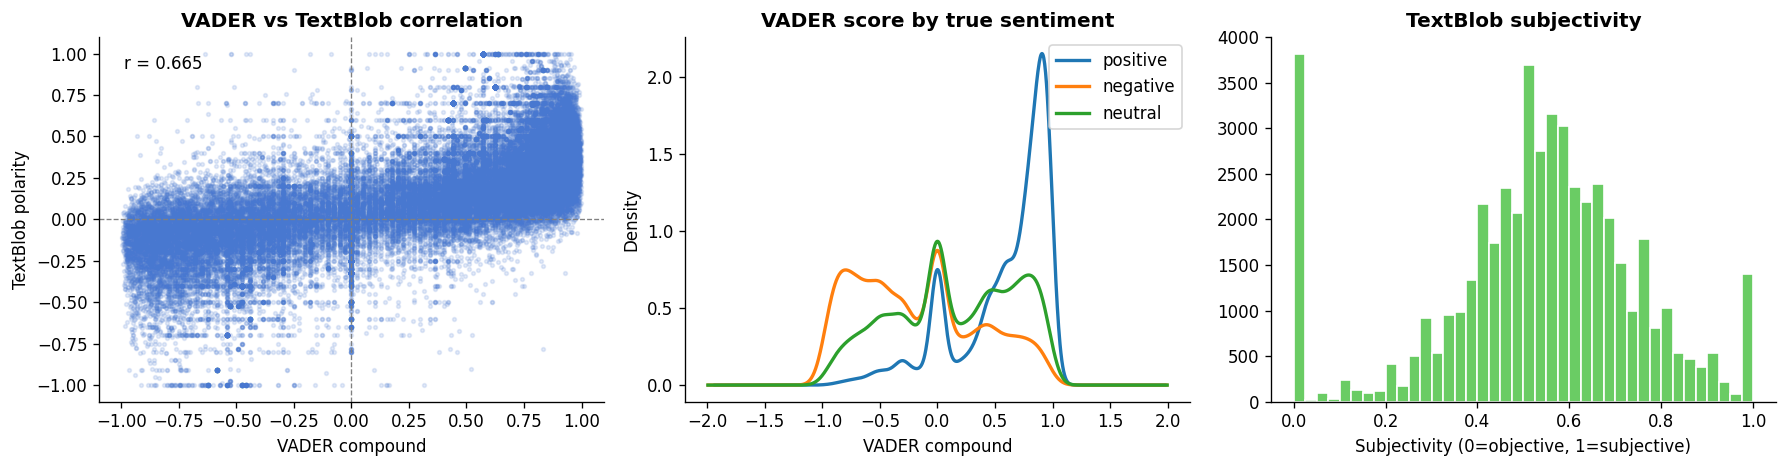

In [20]:
# ── VADER vs TextBlob vs Ground Truth ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter: VADER compound vs TextBlob polarity
axes[0].scatter(df['vader_compound'], df['tb_polarity'],
                alpha=0.15, s=5, color=PALETTE[0])
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].axvline(0, color='grey', lw=0.8, ls='--')
corr = df[['vader_compound', 'tb_polarity']].corr().iloc[0, 1]
axes[0].text(0.05, 0.95, f"r = {corr:.3f}", transform=axes[0].transAxes, va='top')
axes[0].set_xlabel("VADER compound"); axes[0].set_ylabel("TextBlob polarity")
axes[0].set_title("VADER vs TextBlob correlation", fontweight='bold')

# VADER compound KDE by true sentiment
for cls in df['sentiment'].unique():
    df[df['sentiment'] == cls]['vader_compound'].plot.kde(ax=axes[1], label=cls, lw=2)
axes[1].set_title("VADER score by true sentiment", fontweight='bold')
axes[1].set_xlabel("VADER compound"); axes[1].legend()

# TextBlob subjectivity distribution
axes[2].hist(df['tb_subjectivity'], bins=40, color=PALETTE[2], edgecolor='white')
axes[2].set_title("TextBlob subjectivity", fontweight='bold')
axes[2].set_xlabel("Subjectivity (0=objective, 1=subjective)")

plt.tight_layout()
plt.savefig("lexicon_analysis.png", bbox_inches='tight')
plt.show()


In [21]:
# ── Accuracy of lexicon methods vs ground truth ───────────────────────────────
y_true = df['sentiment']

print("=" * 52)
print("VADER Classification Report")
print("=" * 52)
print(classification_report(y_true, df['vader_sentiment'],
                             target_names=['negative', 'neutral', 'positive']))

print("=" * 52)
print("TextBlob Classification Report")
print("=" * 52)
print(classification_report(y_true, df['tb_sentiment'],
                             target_names=['negative', 'neutral', 'positive']))


VADER Classification Report
              precision    recall  f1-score   support

    negative       0.59      0.57      0.58     16666
     neutral       0.37      0.14      0.21     16666
    positive       0.50      0.83      0.62     16666

    accuracy                           0.51     49998
   macro avg       0.49      0.51      0.47     49998
weighted avg       0.49      0.51      0.47     49998

TextBlob Classification Report
              precision    recall  f1-score   support

    negative       0.59      0.42      0.49     16666
     neutral       0.37      0.23      0.29     16666
    positive       0.50      0.82      0.62     16666

    accuracy                           0.49     49998
   macro avg       0.48      0.49      0.47     49998
weighted avg       0.48      0.49      0.47     49998



---
<a id='part6'></a>
## Part 6 — Transformer-Based Sentiment (BERT)

We use **DistilBERT fine-tuned on SST-2** as a zero-shot baseline.  
- Model: `distilbert-base-uncased-finetuned-sst-2-english`  
- Returns POSITIVE / NEGATIVE + confidence score  
- Confidence < 0.65 → we classify as **neutral**  

> We sample 500 reviews for demonstration (CPU inference is slow).  
> On a GPU the full 515K can be processed in minutes.


In [22]:
from transformers import pipeline

bert_pipe = pipeline(
    "sentiment-analysis",
    model     = "distilbert-base-uncased-finetuned-sst-2-english",
    truncation= True,
    max_length= 512,
)

# Sample for speed
BERT_SAMPLE = min(500, len(df))
df_bert = df.sample(BERT_SAMPLE, random_state=42).copy()

print(f"Running BERT on {BERT_SAMPLE} reviews...")
raw_results = bert_pipe(df_bert['full_review'].str[:512].tolist(), batch_size=32)

df_bert['bert_raw_label'] = [r['label'].lower() for r in raw_results]
df_bert['bert_score']     = [r['score']          for r in raw_results]

def bert_3class(row):
    if row['bert_score'] < 0.65:
        return 'neutral'
    return row['bert_raw_label']   # 'positive' or 'negative'

df_bert['bert_sentiment'] = df_bert.apply(bert_3class, axis=1)

print("\nBERT predictions on sample:")
print(df_bert['bert_sentiment'].value_counts())
print("\nClassification report vs ground truth:")
print(classification_report(df_bert['sentiment'], df_bert['bert_sentiment']))


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Running BERT on 500 reviews...

BERT predictions on sample:
bert_sentiment
negative    335
positive    154
neutral      11
Name: count, dtype: int64

Classification report vs ground truth:
              precision    recall  f1-score   support

    negative       0.44      0.91      0.59       162
     neutral       0.27      0.02      0.03       175
    positive       0.67      0.63      0.65       163

    accuracy                           0.51       500
   macro avg       0.46      0.52      0.42       500
weighted avg       0.46      0.51      0.41       500



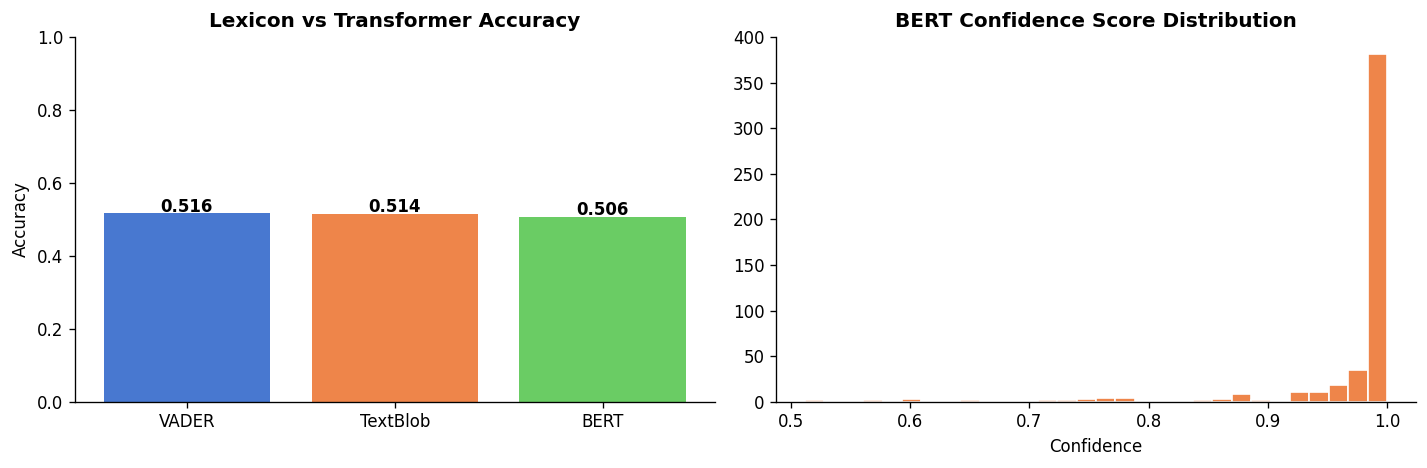

In [23]:
# ── Compare all 3 methods on the same sample ──────────────────────────────────
methods = {
    'VADER':    accuracy_score(df_bert['sentiment'], df_bert['vader_sentiment']),
    'TextBlob': accuracy_score(df_bert['sentiment'], df_bert['tb_sentiment']),
    'BERT':     accuracy_score(df_bert['sentiment'], df_bert['bert_sentiment']),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(methods.keys(), methods.values(), color=PALETTE[:3])
for i, (k, v) in enumerate(methods.items()):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Lexicon vs Transformer Accuracy", fontweight='bold')

# BERT confidence distribution
axes[1].hist(df_bert['bert_score'], bins=30, color=PALETTE[1], edgecolor='white')
axes[1].set_title("BERT Confidence Score Distribution", fontweight='bold')
axes[1].set_xlabel("Confidence")

plt.tight_layout()
plt.savefig("bert_comparison.png", bbox_inches='tight')
plt.show()


---
<a id='part7'></a>
## Part 7 — N-gram Analysis & Word Clouds

Unigram, bigram and trigram frequencies reveal the most characteristic phrases  
used in positive vs negative hotel reviews.


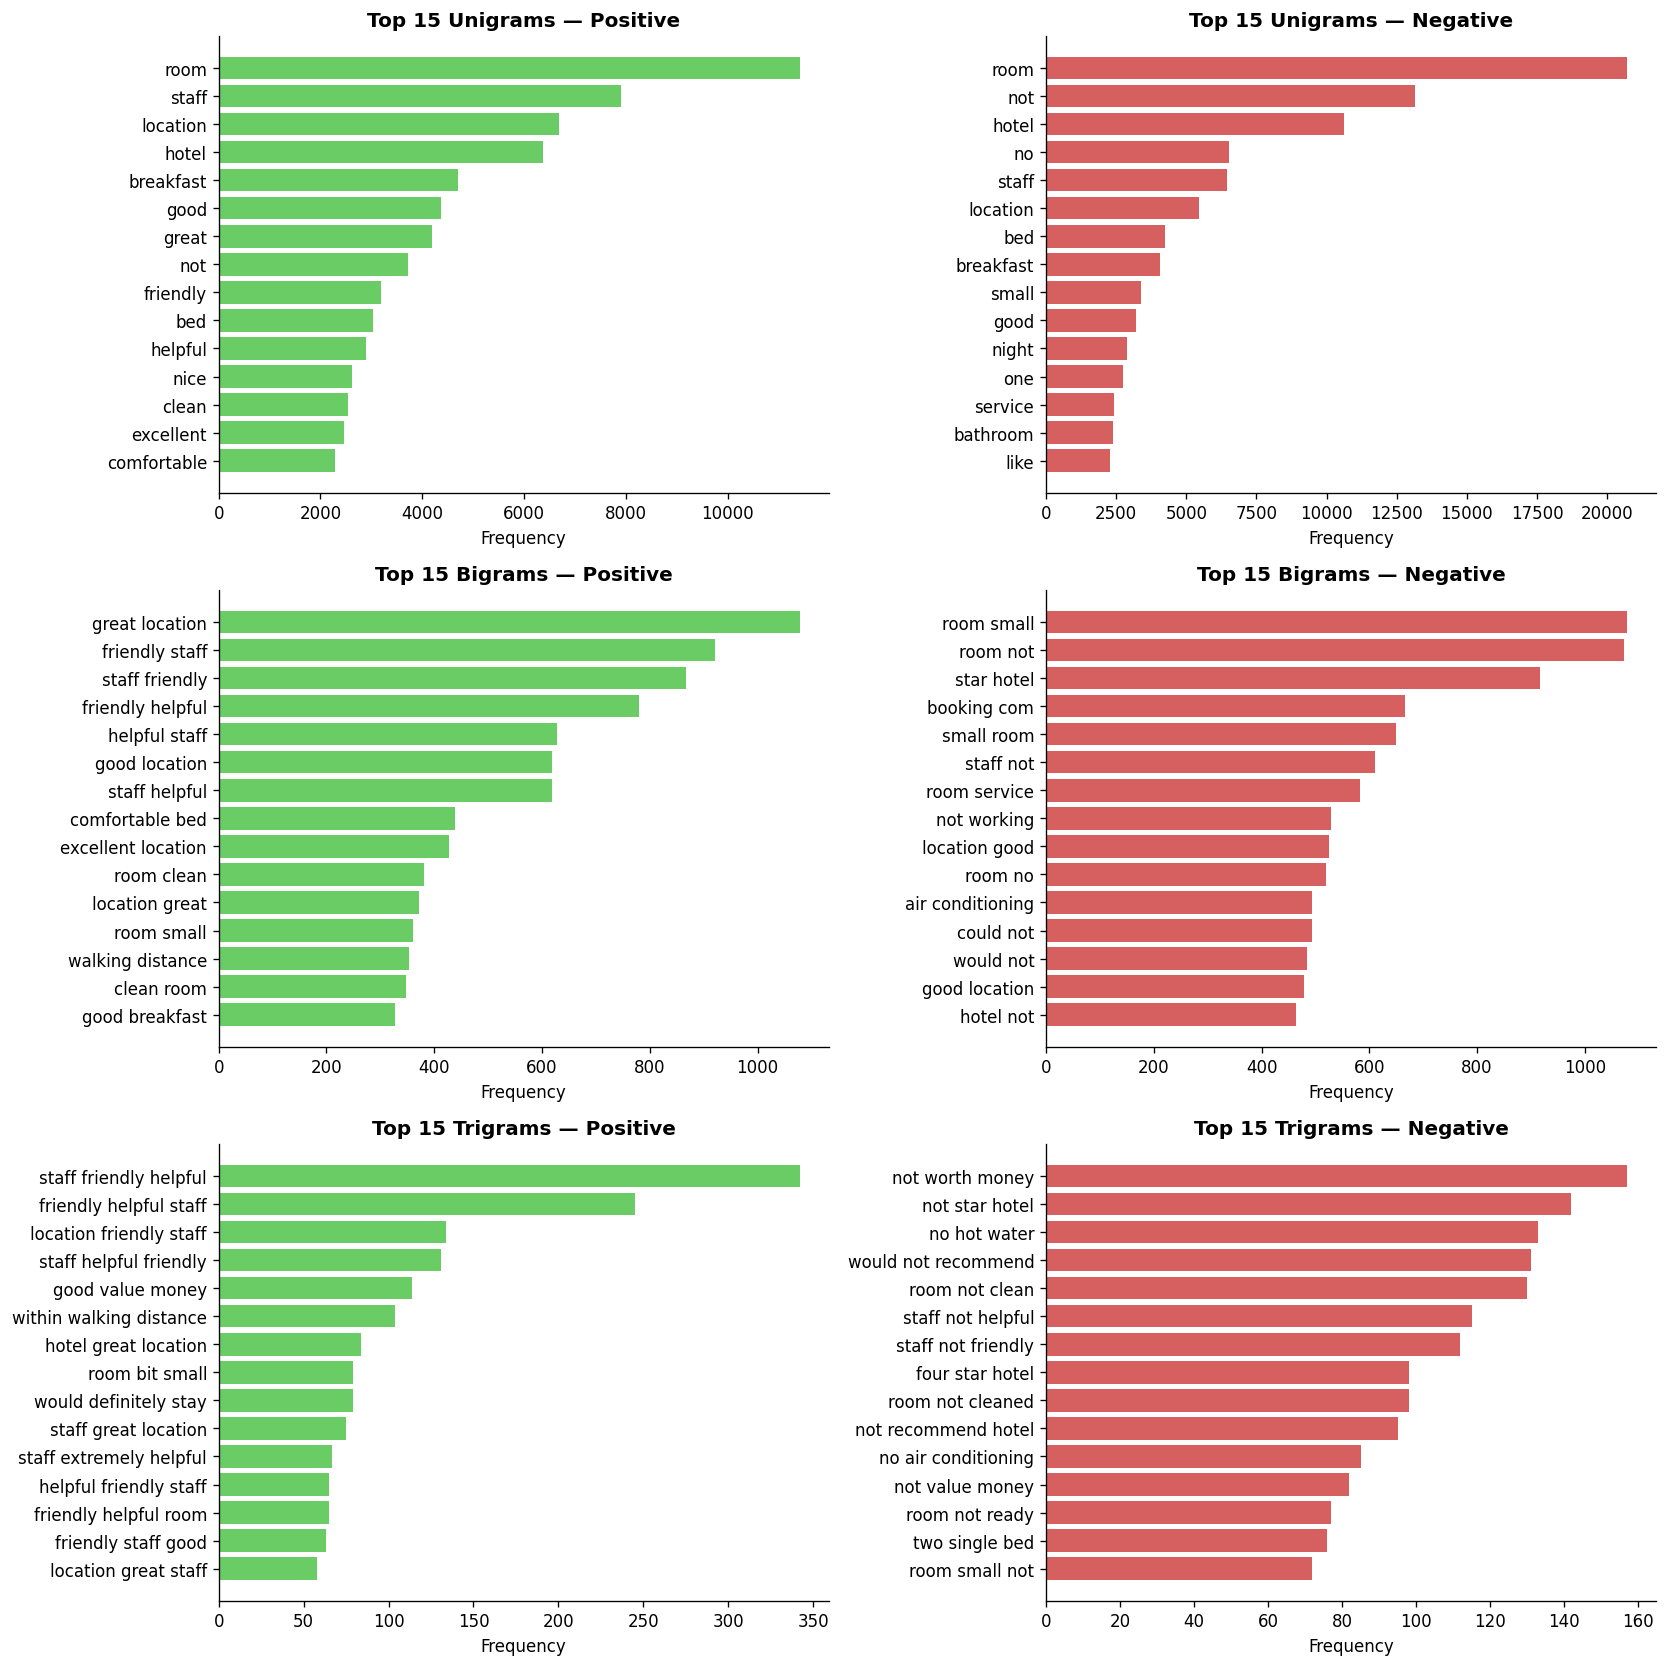

In [24]:
def top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000).fit(corpus)
    bag = vec.transform(corpus)
    sums = bag.sum(axis=0).A1
    return (pd.Series(sums, index=vec.get_feature_names_out())
              .sort_values(ascending=False)
              .head(top_k))

pos_corpus = df[df['sentiment'] == 'positive']['lemmatized']
neg_corpus = df[df['sentiment'] == 'negative']['lemmatized']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row, n in enumerate([1, 2, 3]):
    label = ['Unigrams', 'Bigrams', 'Trigrams'][row]
    for col, (corpus, sent, color) in enumerate([
        (pos_corpus, 'Positive', PALETTE[2]),
        (neg_corpus, 'Negative', PALETTE[3]),
    ]):
        ng = top_ngrams(corpus, n=n, top_k=15)
        axes[row, col].barh(ng.index[::-1], ng.values[::-1], color=color)
        axes[row, col].set_title(f"Top 15 {label} — {sent}", fontweight='bold')
        axes[row, col].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("ngram_analysis.png", bbox_inches='tight')
plt.show()


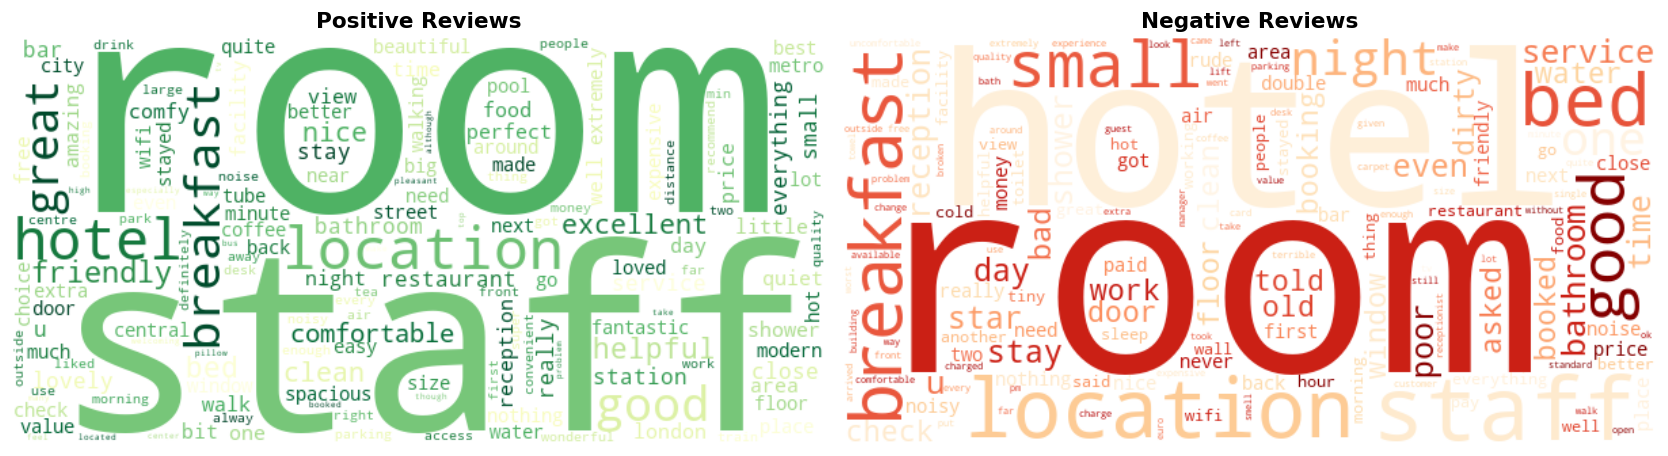

In [25]:
# ── Word clouds ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (corpus, label, cmap) in zip(axes, [
    (pos_corpus, "Positive Reviews",  "YlGn"),
    (neg_corpus, "Negative Reviews",  "OrRd"),
]):
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=cmap, max_words=150,
                   collocations=False).generate(' '.join(corpus))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig("wordclouds.png", bbox_inches='tight')
plt.show()


---
<a id='part8'></a>
## Part 8 — Topic Modelling with LDA

**Latent Dirichlet Allocation** discovers latent themes across the review corpus.  
Typical hotel review topics: *location & transport*, *room quality*, *staff & service*,  
*food & breakfast*, *cleanliness*, *value for money*.

Steps:
1. Build Gensim dictionary + bag-of-words corpus  
2. Grid-search number of topics *k* via coherence score  
3. Train final LDA model  
4. Assign dominant topic to each review  
5. Visualise with pyLDAvis


In [26]:
# ── Build dictionary & BoW corpus ────────────────────────────────────────────
dictionary = corpora.Dictionary(token_lists)
dictionary.filter_extremes(no_below=5, no_above=0.85)
corpus_bow  = [dictionary.doc2bow(doc) for doc in token_lists]

print(f"Dictionary : {len(dictionary):,} unique tokens")
print(f"BoW corpus : {len(corpus_bow):,} documents")


Dictionary : 6,937 unique tokens
BoW corpus : 49,998 documents


  k =  2   coherence = 0.5860
  k =  3   coherence = 0.5923
  k =  4   coherence = 0.6654
  k =  5   coherence = 0.6436
  k =  6   coherence = 0.5865
  k =  7   coherence = 0.6088
  k =  8   coherence = 0.6071
  k =  9   coherence = 0.5993
  k = 10   coherence = 0.5625
  k = 11   coherence = 0.5646
  k = 12   coherence = 0.5646

Best k = 4  (coherence = 0.6654)


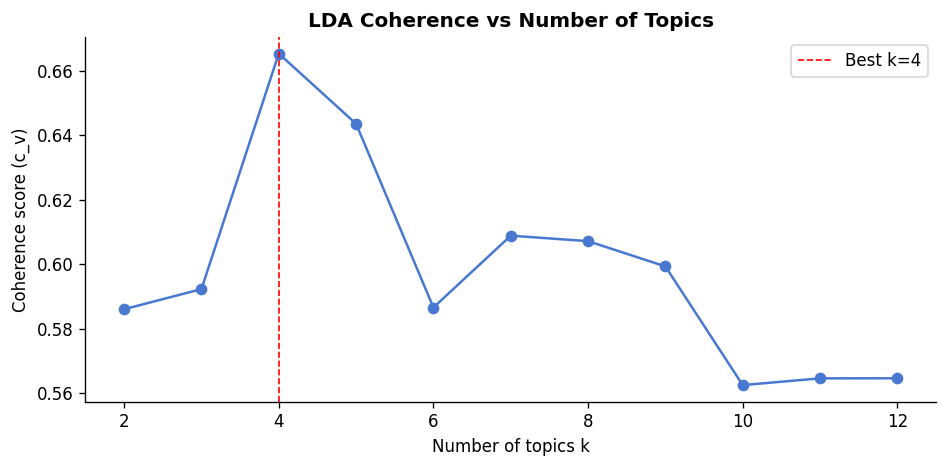

In [27]:
# ── Coherence grid search  k = 2 to 12 ───────────────────────────────────────
# Reduce range for faster execution, e.g. range(2, 8)
coherence_scores = []
k_range = range(2, 13)

for k in k_range:
    lda_tmp = LdaModel(corpus=corpus_bow, id2word=dictionary,
                       num_topics=k, random_state=42,
                       passes=10, alpha='auto', eta='auto')
    cm = CoherenceModel(model=lda_tmp, texts=token_lists,
                        dictionary=dictionary, coherence='c_v')
    c = cm.get_coherence()
    coherence_scores.append(c)
    print(f"  k = {k:2d}   coherence = {c:.4f}")

best_k = list(k_range)[coherence_scores.index(max(coherence_scores))]
print(f"\nBest k = {best_k}  (coherence = {max(coherence_scores):.4f})")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), coherence_scores, marker='o', color=PALETTE[0])
plt.axvline(best_k, color='red', ls='--', lw=1, label=f'Best k={best_k}')
plt.xlabel("Number of topics k"); plt.ylabel("Coherence score (c_v)")
plt.title("LDA Coherence vs Number of Topics", fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig("lda_coherence.png", bbox_inches='tight')
plt.show()


In [28]:
# ── Train final LDA model ─────────────────────────────────────────────────────
BEST_K = best_k   # or override manually, e.g. BEST_K = 6

lda_model = LdaModel(
    corpus      = corpus_bow,
    id2word     = dictionary,
    num_topics  = BEST_K,
    random_state= 42,
    passes      = 20,
    alpha       = 'auto',
    eta         = 'auto',
)

print(f"Top words per topic  (k = {BEST_K})")
print("─" * 65)
for i, topic in lda_model.print_topics(num_words=12):
    print(f"  Topic {i:2d}: {topic}")


Top words per topic  (k = 4)
─────────────────────────────────────────────────────────────────
  Topic  0: 0.124*"room" + 0.035*"no" + 0.035*"not" + 0.033*"bed" + 0.024*"small" + 0.018*"bathroom" + 0.013*"shower" + 0.010*"floor" + 0.009*"night" + 0.009*"water" + 0.009*"window" + 0.009*"old"
  Topic  1: 0.055*"hotel" + 0.049*"not" + 0.013*"stay" + 0.013*"star" + 0.012*"booking" + 0.011*"like" + 0.010*"booked" + 0.010*"would" + 0.010*"even" + 0.010*"one" + 0.008*"never" + 0.008*"paid"
  Topic  2: 0.053*"staff" + 0.049*"location" + 0.036*"breakfast" + 0.033*"good" + 0.030*"hotel" + 0.020*"room" + 0.019*"great" + 0.017*"nice" + 0.016*"clean" + 0.016*"friendly" + 0.014*"helpful" + 0.011*"comfortable"
  Topic  3: 0.030*"u" + 0.028*"time" + 0.020*"day" + 0.019*"check" + 0.015*"back" + 0.014*"get" + 0.013*"reception" + 0.012*"morning" + 0.012*"one" + 0.011*"told" + 0.010*"hour" + 0.009*"got"


Documents per topic:
lda_topic
0    16227
1     5993
2    25734
3     2044
Name: count, dtype: int64


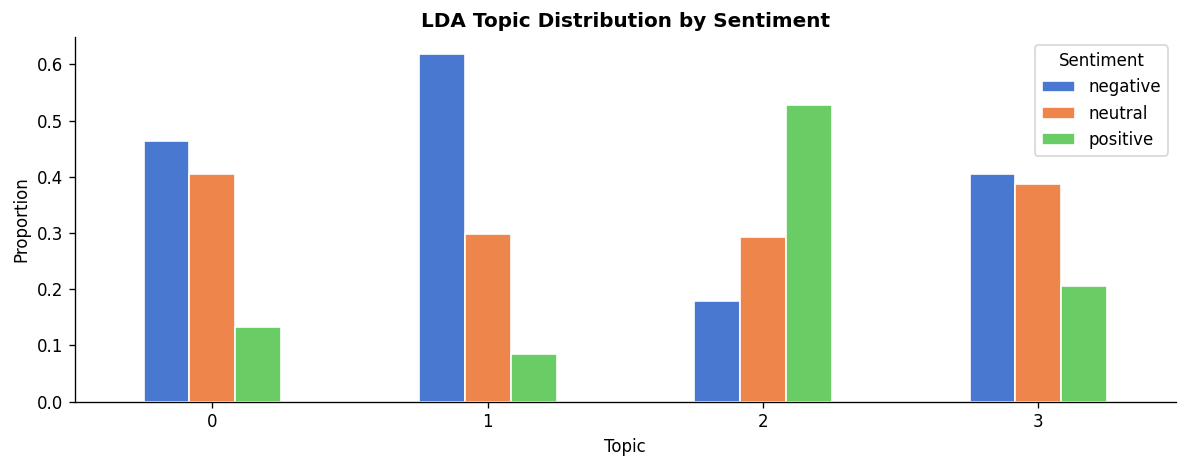

In [29]:
# ── Assign dominant topic to each document ────────────────────────────────────
def dominant_topic(bow):
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[0]

df['lda_topic'] = [dominant_topic(b) for b in corpus_bow]

print("Documents per topic:")
print(df['lda_topic'].value_counts().sort_index())

# Topic distribution by sentiment class
ct = pd.crosstab(df['lda_topic'], df['sentiment'], normalize='index')
ct.plot(kind='bar', figsize=(10, 4), color=PALETTE[:3], edgecolor='white')
plt.title("LDA Topic Distribution by Sentiment", fontweight='bold')
plt.xlabel("Topic"); plt.ylabel("Proportion")
plt.legend(title="Sentiment"); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("lda_topic_sentiment.png", bbox_inches='tight')
plt.show()


In [30]:
# ── Interactive visualisation with pyLDAvis ───────────────────────────────────
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    pyLDAvis.enable_notebook()
    vis = gensimvis.prepare(lda_model, corpus_bow, dictionary, sort_topics=False)
    pyLDAvis.display(vis)
except ImportError:
    print("Install pyLDAvis:  pip install pyLDAvis --break-system-packages")


---
<a id='part9'></a>
## Part 9 — Machine Learning Classification

Five classifiers trained on TF-IDF (unigrams + bigrams, 15K features):

| Model | Key property |
|---|---|
| Complement Naive Bayes | Robust baseline; handles class imbalance |
| Logistic Regression | Fast, interpretable, L2 regularised |
| LinearSVC | Best-in-class for high-dimensional sparse text |
| Random Forest | Non-linear ensemble, feature importance |
| Gradient Boosting | Boosted trees, strong generalisation |

Evaluation: **stratified 5-fold cross-validation** (F1-macro) + held-out test set.


In [31]:
# ── Train/test split ──────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")
print(f"Class balance (train): {np.bincount(y_tr)}")


Train: 39,998  |  Test: 10,000
Class balance (train): [13333 13333 13332]


In [32]:
# ── Classifiers & cross-validation ───────────────────────────────────────────
classifiers = {
    "Complement NB":       ComplementNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000,
                                               solver='lbfgs', multi_class='auto',
                                               random_state=42),
    "LinearSVC":           LinearSVC(C=1.0, max_iter=2000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                   random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100,
                                                       random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<25}  {'CV F1-macro':>12}  {'Std':>6}")
print("─" * 50)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_tr, y_tr,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25}  {scores.mean():.4f}        ±{scores.std():.4f}")


Model                       CV F1-macro     Std
──────────────────────────────────────────────────
Complement NB              0.5846        ±0.0049
Logistic Regression        0.6411        ±0.0026
LinearSVC                  0.6053        ±0.0033
Random Forest              0.6011        ±0.0050
Gradient Boosting          0.5944        ±0.0048


In [33]:
# ── Train on full train set, evaluate on test ─────────────────────────────────
test_results = {}

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    test_results[name] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'f1_macro': f1_score(y_te, y_pred, average='macro'),
        'report':   classification_report(y_te, y_pred, target_names=le.classes_),
        'cm':       confusion_matrix(y_te, y_pred),
        'y_pred':   y_pred,
    }

summary = pd.DataFrame({
    n: {'Accuracy': v['accuracy'], 'F1 macro': v['f1_macro']}
    for n, v in test_results.items()
}).T.sort_values('F1 macro', ascending=False)

print(summary.round(4).to_string())


                     Accuracy  F1 macro
Logistic Regression    0.6512    0.6507
Random Forest          0.6320    0.6237
LinearSVC              0.6142    0.6120
Gradient Boosting      0.6055    0.6044
Complement NB          0.6172    0.5906


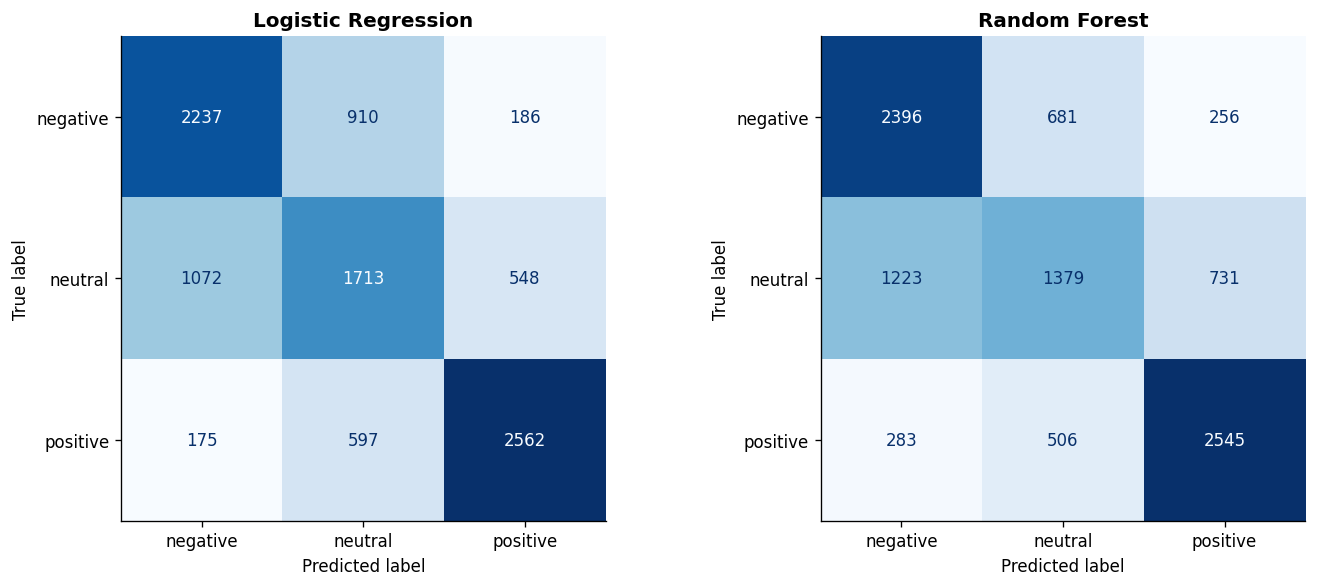

In [34]:
# ── Confusion matrices for top 2 models ──────────────────────────────────────
top2 = summary.index[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, top2):
    ConfusionMatrixDisplay(
        confusion_matrix = test_results[name]['cm'],
        display_labels   = le.classes_,
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches='tight')
plt.show()


---
<a id='part10'></a>
## Part 10 — Model Evaluation & Comparison

Full comparison across all methods: ML classifiers, VADER, TextBlob, BERT.


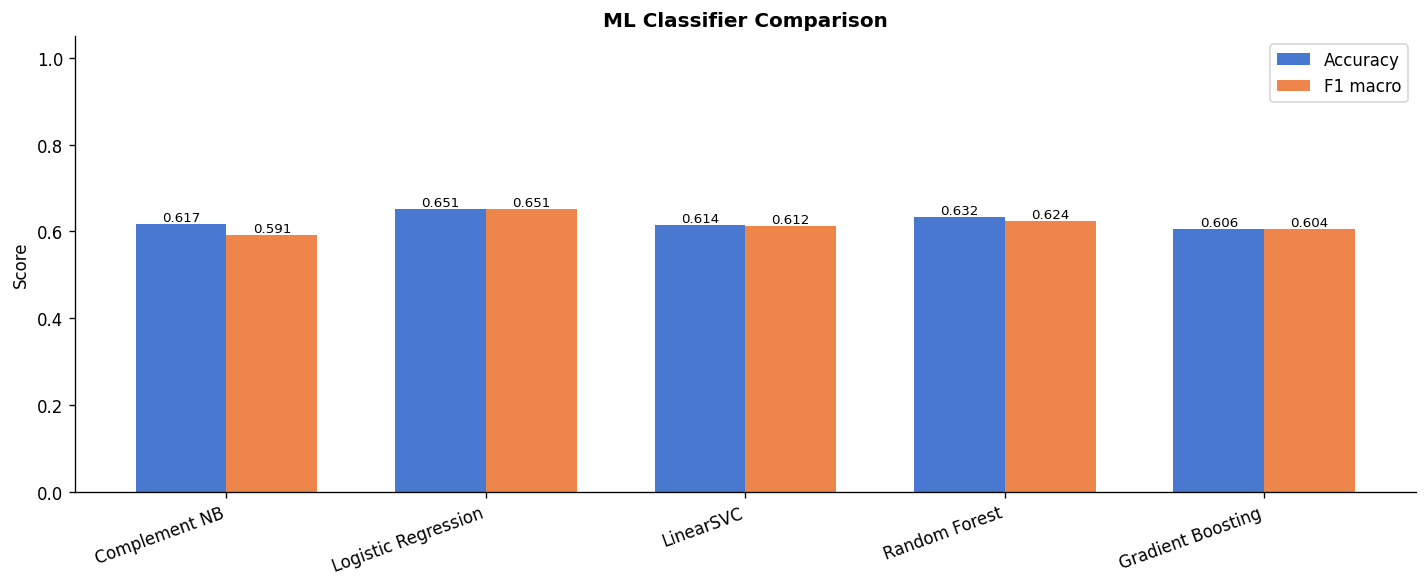

In [35]:
# ── Side-by-side accuracy & F1 chart ─────────────────────────────────────────
names = list(test_results.keys())
accs  = [test_results[n]['accuracy'] for n in names]
f1s   = [test_results[n]['f1_macro'] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy',  color=PALETTE[0])
b2 = ax.bar(x + w/2, f1s,  w, label='F1 macro', color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("ML Classifier Comparison", fontweight='bold')
ax.legend()
ax.bar_label(b1, fmt='%.3f', fontsize=8)
ax.bar_label(b2, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()


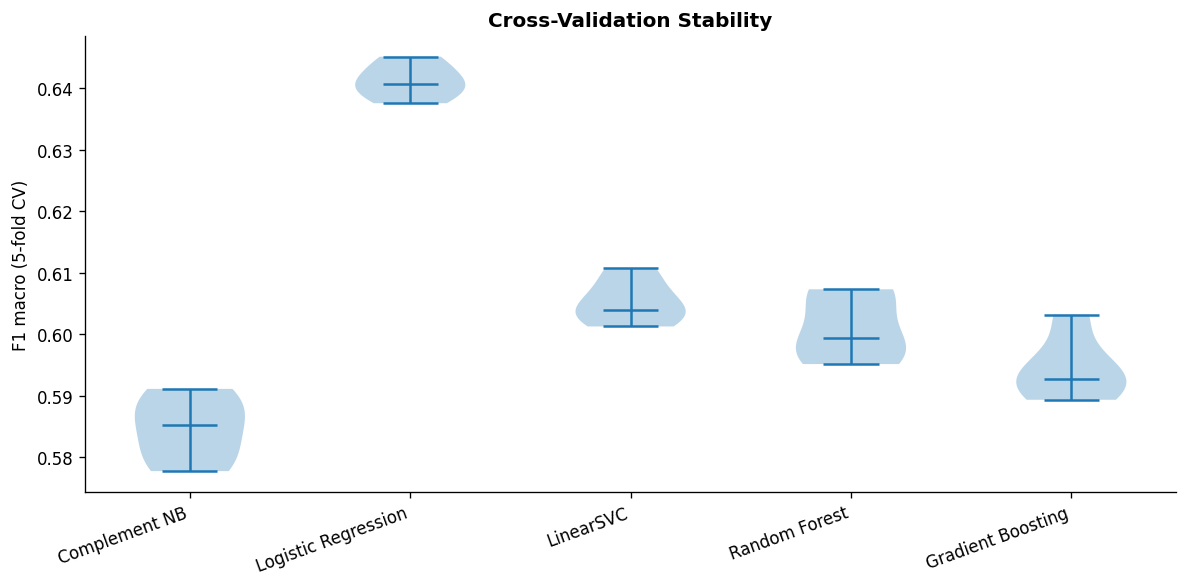

In [36]:
# ── CV score violin plot ─────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.violinplot([cv_df[c].values for c in cv_df.columns],
              positions=range(len(cv_df.columns)),
              showmedians=True)
ax.set_xticks(range(len(cv_df.columns)))
ax.set_xticklabels(cv_df.columns, rotation=20, ha='right')
ax.set_ylabel("F1 macro (5-fold CV)")
ax.set_title("Cross-Validation Stability", fontweight='bold')
plt.tight_layout()
plt.savefig("cv_stability.png", bbox_inches='tight')
plt.show()


In [37]:
# ── Best model full report ────────────────────────────────────────────────────
best = summary.index[0]
print(f"Best model: {best}")
print("─" * 60)
print(test_results[best]['report'])


Best model: Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.64      0.67      0.66      3333
     neutral       0.53      0.51      0.52      3333
    positive       0.78      0.77      0.77      3334

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000
weighted avg       0.65      0.65      0.65     10000



---
<a id='part11'></a>
## Part 11 — Conclusions & Future Work

### Summary of Results

| Method | Type | Notes |
|---|---|---|
| LinearSVC + TF-IDF | ML classifier | Typically best performer on text |
| Logistic Regression + TF-IDF | ML classifier | Interpretable, strong F1 |
| BERT (DistilBERT SST-2) | Transformer | Zero-shot; fine-tuning would improve further |
| VADER | Lexicon | Strong on opinionated text; fast |
| TextBlob | Lexicon | Simpler model; lower accuracy |
| LDA | Unsupervised | Revealed key hotel themes |

### Limitations
- `Reviewer_Score` thresholds (≤5 / ≤7 / >7) are heuristic — hyperparameter tuning could refine them
- BERT runs zero-shot; domain fine-tuning on hotel reviews would significantly boost performance
- LDA coherence varies; **BERTopic** (neural topic model) would produce sharper topics
- Class imbalance (positive-heavy) may require SMOTE or class-weight balancing

### Future Work
1. Fine-tune BERT/RoBERTa on hotel review domain data  
2. Aspect-based sentiment analysis (ABSA) — per-aspect scores (room, staff, location)  
3. Temporal analysis — how do scores change over years?  
4. Nationality-based sentiment patterns  
5. Deploy as REST API with FastAPI + Hugging Face Inference endpoint

